## LSTM  Long Short-Term Memory

The aim of this notebook is to show how to train LSTM on a real synthetic dataset.

### The Training Problem

The problem consist in training a LSTM model to classify a sequence of terms, the two possible outputs are: valid and invalid.

BNF Definition below:

$$
\begin{array}{rcl}
\langle\mathit{string}\rangle   & \mathrel{::=} & \langle\mathit{term}\rangle \\
                              & \mid          & \langle\mathit{string}\rangle \mathbin{\texttt{+}} \langle\mathit{term}\rangle \\[2pt]
\langle\mathit{term}\rangle   & \mathrel{::=} & AB, ED, OK \\[2pt]
\end{array}
$$

The goal is to see if at inference time the model respect the grammar rules and generate valid sequences.

In [266]:
"""Data Generation Utils"""

import numpy as np

ALPHABET = ["A", "B", "D", "O", "E", "K"]
TERMS = ["AB", "ED", "OK"]

def generate_valid_seq(length: int) -> str:
    out = ""
    for _ in range(length):
        ri, = np.random.randint(0, len(TERMS), 1, dtype=int)
        out = f"{out}{TERMS[ri]}"

    return out

def generate_valid_seqs(row: int, col: int) -> list[str]:
    outs = []
    for _ in range(row):
        out = ""
        for _ in range(col):
            ri, = np.random.randint(0, len(TERMS), 1, dtype=int)
            out = f"{out}{TERMS[ri]}"
        outs.append(out)
    
    return outs

def generate_invalid_seq(length: int) -> str:
    out = ""
    for _ in range(length):
        ri, = np.random.randint(0, len(ALPHABET), 1, dtype=int)
        out = f"{out}{ALPHABET[ri]}"

    return out

def generate_invalid_seqs(row: int, col: int) -> list[str]:
    outs = []
    for _ in range(row):
        out = ""
        for _ in range(col):
            ri, = np.random.randint(0, len(ALPHABET), 1, dtype=int)
            out = f"{out}{ALPHABET[ri]}"
        outs.append(out)
    
    return outs

In [267]:
"""Tokenizer"""

VOWELS = {"A", "E", "O"}

def tokenize(input: str | list[str] | list[list[str]]) -> np.ndarray:
    # list of strings / list of lists of strings: recurse elementwise and stack
    if isinstance(input, list):
        return np.stack([tokenize(elem) for elem in input])

    # multi-character string: recurse letter by letter (none of them stand alone)
    if isinstance(input, str) and len(input) > 1:
        return np.stack([tokenize(letter) for letter in input])

    # base case: a single character
    is_vowel = input in VOWELS
    is_consonant = input in ALPHABET and not is_vowel
    position = ALPHABET.index(input) + 1 if input in ALPHABET else 0

    return np.array([is_vowel, is_consonant, position], dtype=np.float32)

VECT_TERMS = {term: tokenize(term) for term in ALPHABET}

In [268]:
"""Grammar Parser"""

def parse(input: str) -> bool:
    prev = None

    for c in input:
        match c:
            case 'A':
                prev = "A"
            case 'B':
                if prev != "A": return False
                prev = ""
            case 'C':
                prev = "C"
            case 'D':
                if prev != "E": return False
                prev = ""
            case 'E':
                prev = "E"
            case 'K':
                if prev != "C": return False
                prev = ""
            
    return True

def parse_vect(input: np.ndarray) -> bool:
    assert len(input.shape) == 2

    prev = None
    for c in input:
        if np.array_equal(c, VECT_TERMS['A']):
            prev = 'A'
        elif np.array_equal(c, VECT_TERMS['B']):
            if prev != 'A': return False
            prev = ''
        elif np.array_equal(c, VECT_TERMS['O']):
            prev = 'O'
        elif np.array_equal(c, VECT_TERMS['D']):
            if prev != 'E': return False
            prev = ''
        elif np.array_equal(c, VECT_TERMS['E']):
            prev = 'E'
        elif np.array_equal(c, VECT_TERMS['K']):
            if prev != 'O': return False
            prev = ''
        else:
            return False
            
    return True

## Tokenizer

In order to represent the terms of the language we need to define a tokenizer that will map every letters of the alphabet to point in a vector space.
Our vector space has 3 dimensions:

- Is Vowel
- Is Consonant
- Position in alphabet

so every term will be represented as a 4D vector in this space.

In [269]:
"""Dataset Generation"""

from thorcino.dataset.dataset import DataLoader, TensorDataset
from thorcino.tensor import Tensor


SPLIT_RATIO = 0.8
BATCH_SIZE = 16
N_SEQ, LEN_SEQ = 100, 20
TRAIN_LEN = int(N_SEQ*SPLIT_RATIO)

X_valid = np.array(tokenize(generate_valid_seqs(N_SEQ, LEN_SEQ)))
X_invalid = np.array(tokenize(generate_invalid_seqs(N_SEQ, LEN_SEQ*2)))

In [270]:
for seq in X_valid:
    assert parse_vect(seq) == True

for seq in X_invalid:
    assert parse_vect(seq) == False

In [271]:
X = np.append(X_valid, X_invalid, axis=0)
np.random.shuffle(X)

Y = [np.array([parse_vect(seq)], dtype=np.float32) for seq in X]
Y = np.array(Y)

X_train, X_test = X[:TRAIN_LEN], X[TRAIN_LEN:]
Y_train, Y_test = Y[:TRAIN_LEN], Y[TRAIN_LEN:]

In [272]:
for seq, is_valid in zip(X, Y):
    assert parse_vect(seq) == is_valid.flatten()[0]

In [273]:
train_dataset, test_dataset = TensorDataset(Tensor(X_train), Tensor(Y_train)), TensorDataset(Tensor(X_test), Tensor(Y_test))
train_dataloader, test_dataloader = DataLoader(train_dataset, BATCH_SIZE, True), DataLoader(test_dataset, BATCH_SIZE, True)

In [274]:
"""Model Architecture"""

from thorcino.activations import Sigmoid
from thorcino.layers.linear import Linear
from thorcino.layers.lstm import LSTM
from thorcino.layers.sequential import Sequential
from thorcino.losses import MSELoss
from thorcino.optimizer import SGD
from thorcino.training.schedulers import CosineSchedule
from thorcino.training.trainer import Trainer

EPOCHS, EVAL_STEP = 80, 5
MAX_LR, MIN_LR = 1e-2, 1e-5

model = Sequential(
    LSTM(
        in_feature=3,
        hidden_units=3,
        out_type='n_to_1',
    ),
    Linear(
        in_feature=3,
        out_feature=1,
    ),
    Sigmoid()
)
loss = MSELoss()
optimizer = SGD(model.parameters, MAX_LR)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(
    model,
    loss,
    optimizer,
    scheduler,
)

#model.save_arch('./images/arch.png', X_train.shape)
#model.save_forward('./images/arch.png', X_train.shape)
#model.save_backward('./images/arch.png', X_train.shape)

In [275]:
"""Training"""

train_loss, eval_loss, accuracy = [], [], []
for e in range(EPOCHS):
    loss = trainer.train_epoch(train_dataloader)

    train_loss.append(loss)

    if e%EVAL_STEP == 0:
        loss, acc = trainer.eval(test_dataloader)

        eval_loss.append(loss)
        accuracy.append(acc)

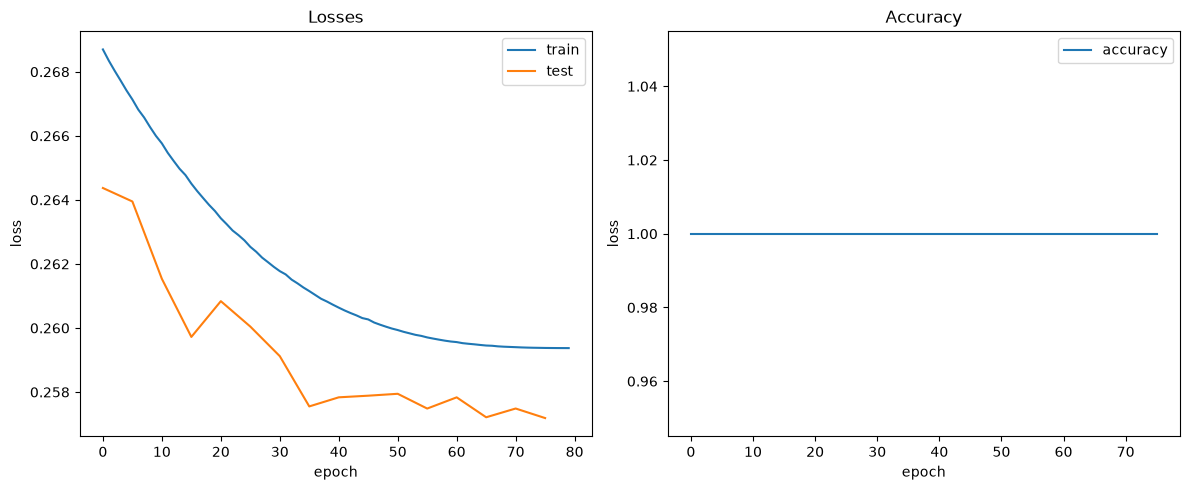

In [276]:
"""Plot Metrics"""

import matplotlib.pyplot as plt

fig, (loss_ax, accuracy_ax) = plt.subplots(1, 2, figsize=(12, 5))

loss_ax.plot(range(EPOCHS), train_loss, label="train")
loss_ax.plot(range(0, EPOCHS, EVAL_STEP), eval_loss, label="test")
loss_ax.set_title("Losses")
loss_ax.set_xlabel("epoch")
loss_ax.set_ylabel("loss")
loss_ax.legend()

accuracy_ax.set_title("Accuracy")
accuracy_ax.plot(range(0, EPOCHS, EVAL_STEP), accuracy, label="accuracy")
accuracy_ax.set_xlabel("epoch")
accuracy_ax.set_ylabel("loss")
accuracy_ax.legend()

fig.tight_layout()
plt.show()

In [277]:
"""Inference"""

def infer(model: Sequential, X: Tensor) -> np.ndarray:
    model.eval()
    preds = model(X)
    model.train()

    return preds

seq, is_valid = X_test[np.newaxis, 0], Y_test[0]
print(seq.shape, is_valid)

pred = infer(model, Tensor(seq))

print(pred)

(1, 40, 3) [0.]
Tensor([[0.5034515]])
